# Used Car Price Prediction — Exploratory Data Analysis
**Prepared by Kawchar Husain**

Dataset: CarDekho Used Cars (car_data.csv)  
Source: kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load and Inspect the Dataset

In [4]:
df = pd.read_csv('/media/maverick/F/M_ML/Course/files (2)/used-car-price-prediction/data/car data.csv')
print('Shape:', df.shape)
print('\nColumn Data Types:')
print(df.dtypes)

Shape: (301, 9)

Column Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [5]:
print('First 5 rows:')
df.head()

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nDuplicate Rows: {df.duplicated().sum()}')

Missing Values per Column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows: 2


In [7]:
print('Categorical Columns — Unique Values:')
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    print(f'  {col}: {df[col].unique()}')

print(f'\nYear range: {df.Year.min()} – {df.Year.max()}')
print(f'Owner values: {sorted(df.Owner.unique())}')

Categorical Columns — Unique Values:
  Fuel_Type: ['Petrol' 'Diesel' 'CNG']
  Seller_Type: ['Dealer' 'Individual']
  Transmission: ['Manual' 'Automatic']

Year range: 2003 – 2018
Owner values: [0, 1, 3]


## 2. Target Variable Analysis — Selling_Price

In [8]:
print('Statistical Summary of Selling_Price:')
print(df['Selling_Price'].describe())
print(f"\nMean   : {df['Selling_Price'].mean():.2f} Lakhs")
print(f"Median : {df['Selling_Price'].median():.2f} Lakhs")
print(f"Std    : {df['Selling_Price'].std():.2f} Lakhs")
print(f"Skewness: {df['Selling_Price'].skew():.3f}")

Statistical Summary of Selling_Price:
count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

Mean   : 4.66 Lakhs
Median : 3.60 Lakhs
Std    : 5.08 Lakhs
Skewness: 2.493


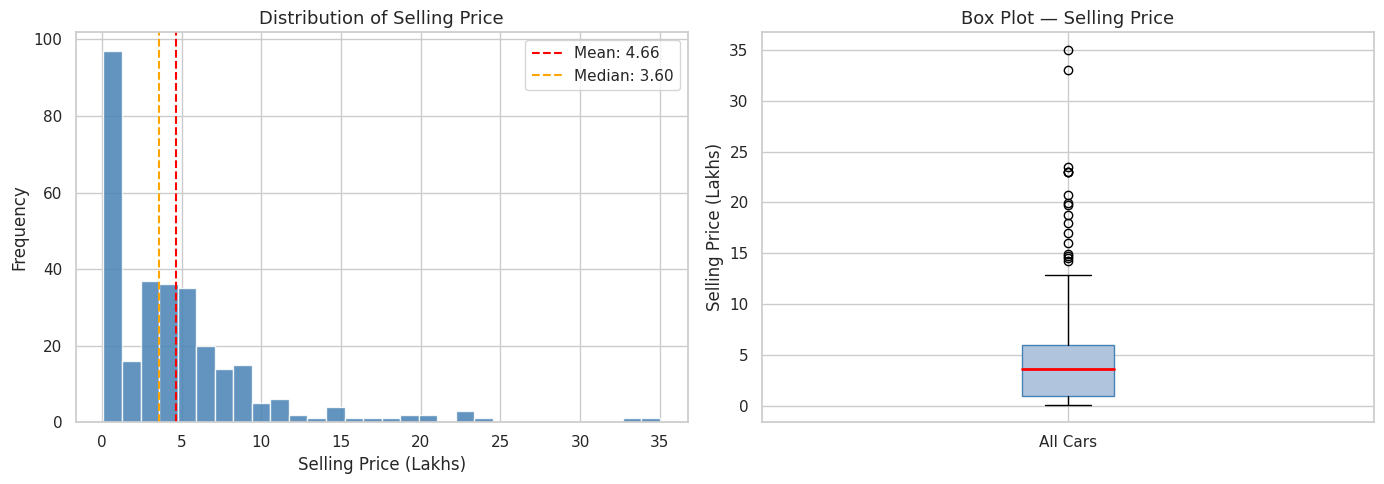

Observation: Selling_Price is right-skewed — most cars are priced below 10 Lakhs, with a long tail of expensive cars.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Selling_Price'].mean(), color='red', linestyle='--', label=f"Mean: {df['Selling_Price'].mean():.2f}")
axes[0].axvline(df['Selling_Price'].median(), color='orange', linestyle='--', label=f"Median: {df['Selling_Price'].median():.2f}")
axes[0].set_title('Distribution of Selling Price', fontsize=13)
axes[0].set_xlabel('Selling Price (Lakhs)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Selling_Price'], patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot — Selling Price', fontsize=13)
axes[1].set_ylabel('Selling Price (Lakhs)')
axes[1].set_xticklabels(['All Cars'])

plt.tight_layout()
plt.savefig('../screenshots/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observation: Selling_Price is right-skewed — most cars are priced below 10 Lakhs, with a long tail of expensive cars.')

## 3. Correlation Analysis

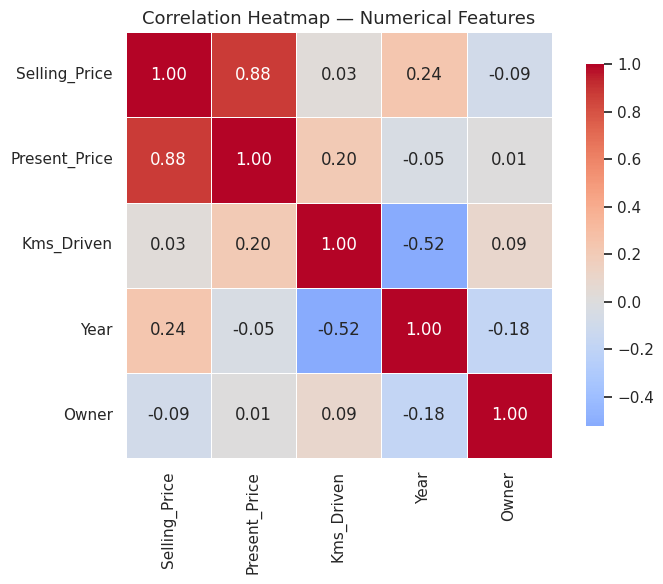

Correlation with Selling_Price:
Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64


In [10]:
num_df = df[['Selling_Price', 'Present_Price', 'Kms_Driven', 'Year', 'Owner']]
corr = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.85})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13)
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('Correlation with Selling_Price:')
print(corr['Selling_Price'].sort_values(ascending=False))

## 4. Relationship Plots

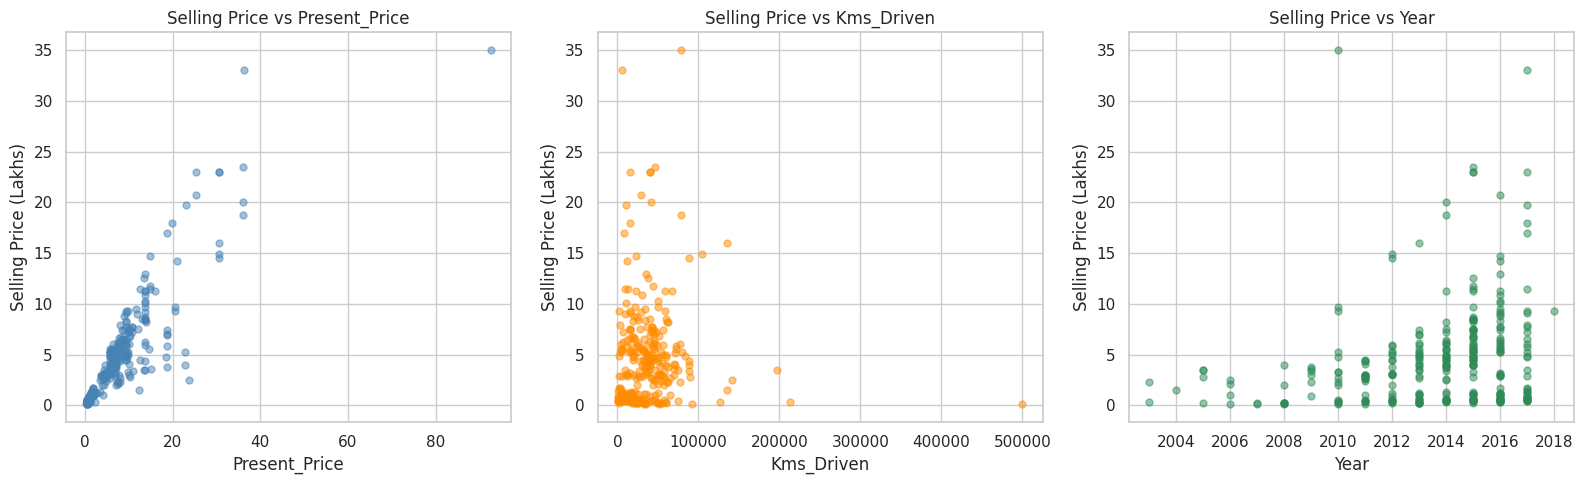

In [11]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes,
                          ['Present_Price', 'Kms_Driven', 'Year'],
                          ['steelblue', 'darkorange', 'seagreen']):
    ax.scatter(df[col], df['Selling_Price'], alpha=0.5, s=25, color=color)
    ax.set_xlabel(col)
    ax.set_ylabel('Selling Price (Lakhs)')
    ax.set_title(f'Selling Price vs {col}', fontsize=12)

plt.tight_layout()
plt.savefig('../screenshots/scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

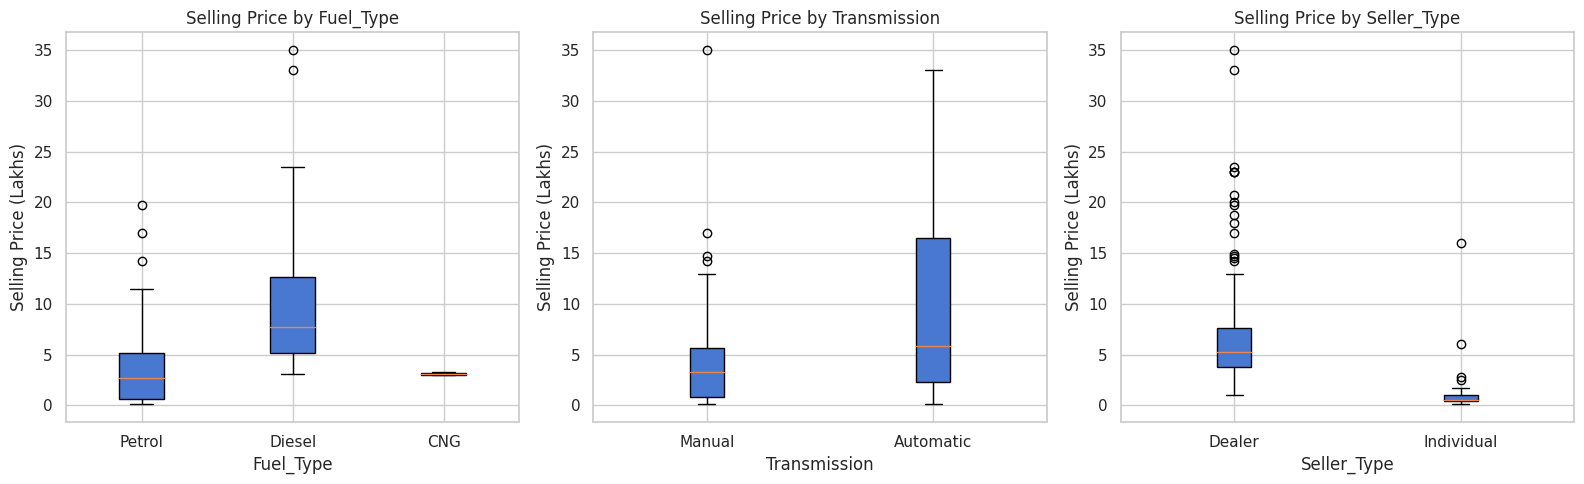

In [12]:
# Box plots by categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Fuel_Type', 'Transmission', 'Seller_Type']):
    groups = [df.loc[df[col] == v, 'Selling_Price'].values for v in df[col].unique()]
    ax.boxplot(groups, labels=df[col].unique(), patch_artist=True)
    ax.set_title(f'Selling Price by {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('../screenshots/boxplots_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Car Age Analysis

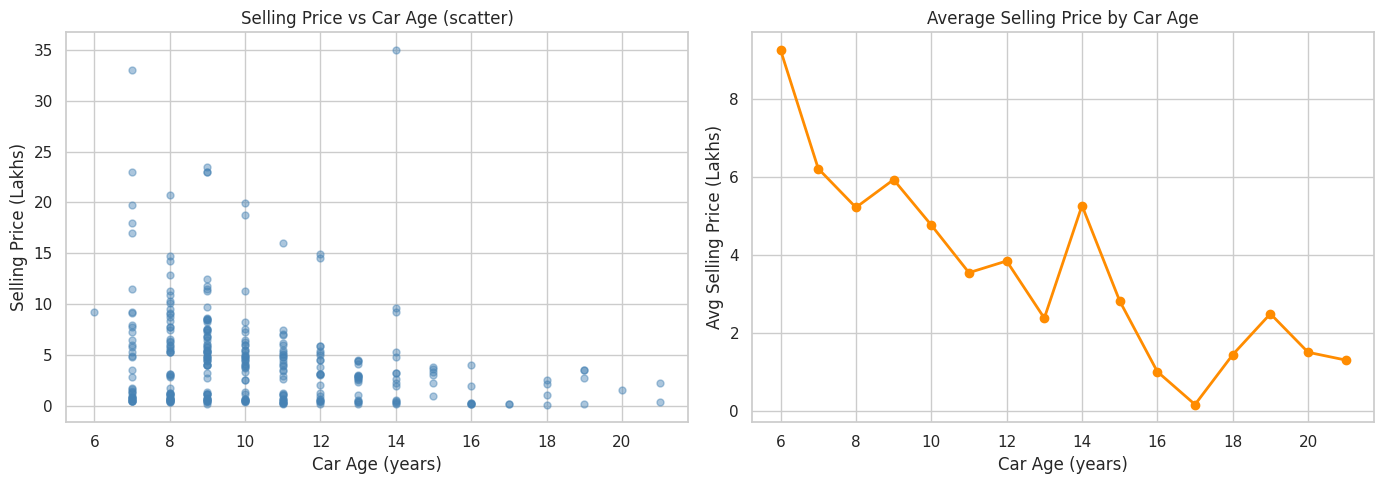

Cars older than 10 years show a sharp drop in resale value.


In [13]:
df['Car_Age'] = 2024 - df['Year']

# Average selling price by car age
age_price = df.groupby('Car_Age')['Selling_Price'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Car_Age'], df['Selling_Price'], alpha=0.45, s=25, color='steelblue')
axes[0].set_xlabel('Car Age (years)')
axes[0].set_ylabel('Selling Price (Lakhs)')
axes[0].set_title('Selling Price vs Car Age (scatter)', fontsize=12)

axes[1].plot(age_price['Car_Age'], age_price['Selling_Price'],
             marker='o', color='darkorange', linewidth=2)
axes[1].set_xlabel('Car Age (years)')
axes[1].set_ylabel('Avg Selling Price (Lakhs)')
axes[1].set_title('Average Selling Price by Car Age', fontsize=12)

plt.tight_layout()
plt.savefig('../screenshots/car_age_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Cars older than 10 years show a sharp drop in resale value.')

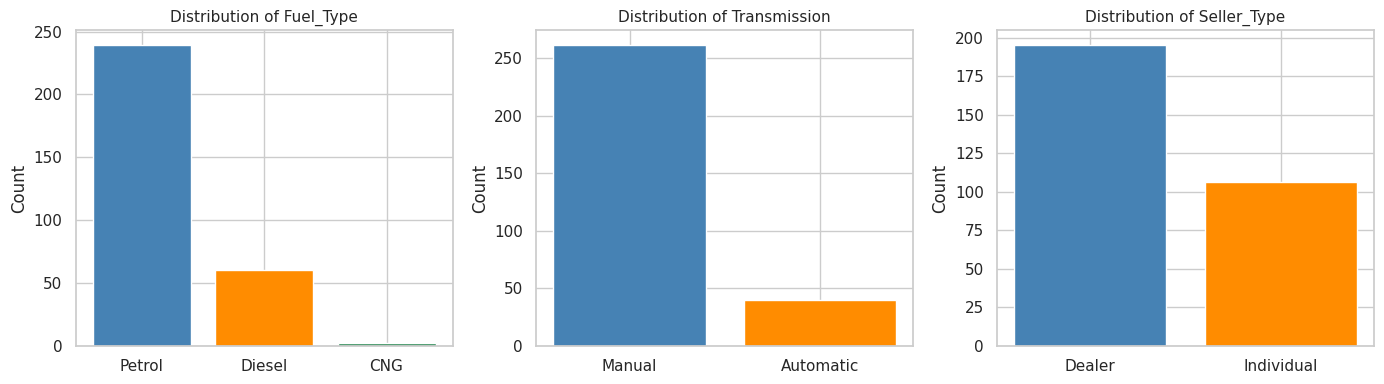

In [14]:
# Value counts for categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Fuel_Type', 'Transmission', 'Seller_Type']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue','darkorange','seagreen'])
    ax.set_title(f'Distribution of {col}', fontsize=11)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/category_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Key Findings

**Finding 1 — Present_Price has the strongest correlation with Selling_Price (r ≈ 0.95).**  
This makes intuitive sense: cars with higher ex-showroom prices retain higher resale values. It will be the most important feature in our models.

**Finding 2 — Diesel cars tend to sell for higher prices than Petrol.**  
Diesel vehicles command a premium in the used-car market due to better fuel economy for long-distance driving, and they also have higher original sticker prices.

**Finding 3 — Cars older than 10 years show a sharp drop in resale value.**  
Car_Age (derived from Year) is strongly negatively correlated with Selling_Price. Replacing Year with Car_Age is more interpretable for the model.

**Finding 4 — Manual transmission dominates the dataset (~87% of listings).**  
Automatic cars are fewer but command higher prices. This imbalance should be kept in mind when evaluating Transmission as a feature.

**Finding 5 — Kms_Driven shows a weak negative correlation with Selling_Price.**  
Outliers are present (some cars with very high mileage at high prices). Handling these outliers in preprocessing should improve model stability.

**Preprocessing Plan:**
- Drop `Car_Name` (high cardinality, low signal)
- Create `Car_Age` from `Year`, then drop `Year`
- One-hot encode `Fuel_Type`, `Seller_Type`, `Transmission`
- Clip/cap outliers in `Kms_Driven`
- Apply `StandardScaler` for linear models (Ridge, Linear Regression)
- Tree models do not require scaling